# Privacy Auditing

Privacy accounting gives *theoretical* upper bounds on privacy loss.
Privacy auditing gives *empirical* lower bounds by running a
membership inference attack. If the audited epsilon exceeds the
theoretical bound, there is likely a bug.

This notebook runs the full auditing workflow end-to-end:
partition canaries, train with DP-SGD, score, and estimate epsilon.

We use **random labels** — a standard stress-test that forces the
model to memorize training data, producing a strong membership
inference signal.

**Prerequisites:** Familiarity with DP-SGD (see the
[DP-SGD training tutorial](dp_sgd_training.ipynb)).

**Components:** `coin_flip`, `loss_scores`, `one_run`,
`OneRunEstimate`.

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, default_collate

import opake.accounting as acc
import opake.dpsgd.accounting as dpsgd_acc
import opake.auditing as auditing
from opake.dpsgd.clipping import clipped_grad
from opake.dpsgd.noise import gaussian_noise
from opake.dpsgd.sampling import PoissonSampler
from opake.functional import empty_collate, make_functional
from opake.random import key

torch.manual_seed(42)

## Dataset and model

Random labels cannot be learned by generalization — the model
must memorize. A small MLP has enough capacity to overfit,
producing a clear gap between in-member and out-member losses.

In [2]:
n_samples, n_features = 500, 10
X = torch.randn(n_samples, n_features)
y = torch.randint(0, 2, (n_samples,)).float()  # random labels
dataset = TensorDataset(X, y)

model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)
fmodel, params = make_functional(model)


def loss_fn(params, x, y):
    logit = fmodel(params, x.unsqueeze(0)).squeeze()
    return F.binary_cross_entropy_with_logits(logit, y)

## Step 1 — Partition canaries

`coin_flip()` randomly selects canary examples and flips a fair
coin for each: *in* (included in training) or *out* (held out).
Here every random-labelled record is a constructed canary, so
`candidate_indices` explicitly designates the complete pool.

In [3]:
num_canaries = n_samples  # audit every example
cf = auditing.coin_flip(
    dataset,
    num_canaries=num_canaries,
    key=key(42),
    candidate_indices=range(n_samples),
)
train_data = cf.train_subset(dataset)

print(f"Dataset:      {n_samples} examples")
print(
    f"Canaries:     {num_canaries} ({len(cf.in_indices)} in, {len(cf.out_indices)} out)"
)
print(f"Training set: {len(train_data)} examples")

Dataset:      500 examples
Canaries:     500 (249 in, 251 out)
Training set: 249 examples


## Step 2 — Set up DP-SGD and compute reference scores

Before training we record each canary’s loss on the
untrained model. The final membership scores will be the
loss *reduction* from training (Steinke et al., Algorithm 3).

In [4]:
batch_size = 64
clipping_norm = 1.0
noise_multiplier = 0.5
expected_participations = 200
sample_rate = batch_size / (n_samples / 2)
total_steps = round(expected_participations / sample_rate)
lr = 0.5

grad_fn, clip_state = clipped_grad(
    loss_fn,
    argnums=0,
    batch_argnums=(1, 2),
    clipping_norm=clipping_norm,
    normalize_by=batch_size,
)
noise_fn, noise_state = gaussian_noise(
    noise_multiplier=noise_multiplier,
    key=key(0),
)

# Score canaries on the untrained model. Passing coin_flip= and dataset=
# makes the scorer build its own canary loader and bind every score to
# the dataset index of its canary.
ref_scores = auditing.loss_scores(
    loss_fn,
    params,
    batch_argnums=(1, 2),
    coin_flip=cf,
    dataset=dataset,
    batch_size=batch_size,
)
print(
    f"Reference scores: mean={ref_scores.scores.mean():.4f}, "
    f"std={ref_scores.scores.std():.4f}"
)

Reference scores: mean=-0.6962, std=0.0922


## Step 3 — Train

In [5]:
sampler = PoissonSampler(train_data, sample_rate=sample_rate, n_steps=total_steps, key=key(1))
collate = empty_collate(default_collate)
collate([train_data[0]])
train_loader = DataLoader(train_data, batch_sampler=sampler, collate_fn=collate)

for step, (xb, yb) in enumerate(train_loader):
    grads, clip_state = grad_fn(params, xb, yb, state=clip_state)
    noisy_grads, noise_state = noise_fn(grads, noise_state)
    params = tuple(p - lr * g for p, g in zip(params, noisy_grads.pytree))

    if (step + 1) % (total_steps // 4) == 0:
        with torch.no_grad():
            logits = fmodel(params, X[:200]).squeeze()
            accuracy = (logits > 0).float().eq(y[:200]).float().mean()
        print(f"Step {step + 1:3d}  accuracy={accuracy:.1%}")

assert step + 1 == total_steps

Step 195  accuracy=65.0%


Step 390  accuracy=63.5%


Step 585  accuracy=67.0%


Step 780  accuracy=67.5%


## Step 4 — Score canaries and estimate epsilon

`loss_scores()` computes per-canary membership scores (negated loss)
using `vmap`. Passing `reference_scores` subtracts the untrained
baseline so the score measures *loss reduction* from training.

Scoring with `coin_flip=` + `dataset=` returns `CanaryScores`: each
score carries the dataset index of its canary. `one_run()` joins the
scores to the coin-flip labels by those identifiers — wrong, missing,
or duplicated identifiers raise instead of silently pairing scores
with the wrong labels.

`one_run()` then builds a `OneRunEstimate`. The estimate exposes a
PLD-mirror surface (`epsilon_at`, `delta_at`, `beta_at`, `advantage`)
that defaults to the **μ-GDP order-statistics test**
(Xiang et al. 2025) — the tight choice for Gaussian-DP mechanisms like
DP-SGD. The mechanism-agnostic (ε, δ)-DP fallback is available via
`estimate.eps_delta()`.

In [6]:
scores = auditing.loss_scores(
    loss_fn,
    params,
    batch_argnums=(1, 2),
    coin_flip=cf,
    dataset=dataset,
    batch_size=batch_size,
    reference_scores=ref_scores,
)

estimate = auditing.one_run(scores, coin_flip=cf)

## Results

Compare the empirical epsilon from the audit against the
theoretical bound from privacy accounting.

In [7]:
# Theoretical bound from privacy accounting
process = dpsgd_acc.poisson(dpsgd_acc.gaussian(noise_multiplier), sample_rate) * total_steps
theoretical_eps = process.epsilon_at(1e-5)

delta = 1e-5
# Default audit method: μ-GDP (Xiang et al. 2025) — tightest for DP-SGD.
audited_eps = estimate.epsilon_at(delta=delta)
# Mechanism-agnostic (ε, δ)-DP fallback (for non-Gaussian-DP mechanisms):
audited_eps_general = estimate.eps_delta().epsilon_at(delta=delta)

print(f"Audited ε (μ-GDP, default): {audited_eps:.2f}")
print(f"Audited ε ((ε,δ)-DP):       {audited_eps_general:.2f}")
print(f"Theoretical ε:              {theoretical_eps:.2f}")
if audited_eps <= theoretical_eps:
    print("OK: audited epsilon is within the theoretical bound.")
else:
    print("WARNING: audited epsilon exceeds theoretical bound.")

Audited ε (μ-GDP, default): 2.24
Audited ε ((ε,δ)-DP):       0.51
Theoretical ε:              311.45
OK: audited epsilon is within the theoretical bound.


The audited epsilon should be *below* the theoretical bound.

**Why is the gap so large?** Privacy auditing is a *black-box*
method: it can only detect leakage that its specific membership
inference attack (here, loss thresholding) can exploit. The
theoretical bound, by contrast, holds against *all* possible
adversaries, including ones far more powerful than any single
MIA. The audited epsilon is therefore a *lower bound* on the
true privacy leakage — it tells you "at least this much leaks,"
but the actual leakage could be anywhere between the audited and
theoretical values. A stronger canary design or attack may narrow
the gap; a small lower bound is not a privacy certificate.

## Attack metrics

AUC measures how well this adversary can distinguish in-members
from out-members. Values near 0.5 mean this attack found little
signal, not that the model necessarily leaks little.

In [8]:
print(f"Attack AUC:        {estimate.attack_auc():.3f}")
print(f"Attack β @ α=0.01: {estimate.attack_beta_at(alpha=0.01):.3f}")

ci = estimate.attack_auc(confidence=0.95, num_samples=1000, key=key(42))
print(f"Attack AUC 95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")

Attack AUC:        0.692
Attack β @ α=0.01: 0.976
Attack AUC 95% CI: [0.644, 0.739]


## Score distributions

Visualize how in-member and out-member scores overlap.
More overlap means better privacy.

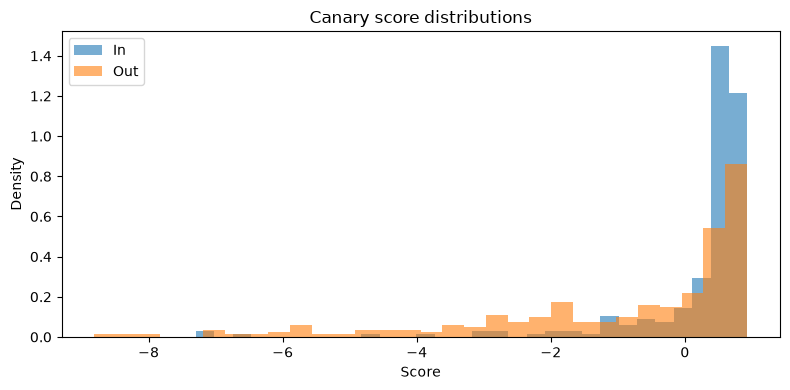

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(estimate.in_scores, bins=30, alpha=0.6, label="In", density=True)
ax.hist(estimate.out_scores, bins=30, alpha=0.6, label="Out", density=True)
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_title("Canary score distributions")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

The auditing workflow is three steps after preparing the data:

1. **Partition** — `auditing.coin_flip(..., candidate_indices=pool)`
2. **Train** — on `cf.train_subset(dataset)` with normal DP-SGD or DP-FTRL
3. **Score & estimate** — `auditing.loss_scores(...)` then
   `auditing.one_run(scores, coin_flip=cf)`, then query
   `estimate.epsilon_at(delta=...)` (default: μ-GDP, tightest for
   Gaussian-DP mechanisms). Use `estimate.eps_delta().epsilon_at(...)`
   for non-Gaussian-DP mechanisms or pure ε-DP.

See `examples/train_dpsgd.py --audit` and
`examples/train_dpftrl.py --audit` for complete LLM examples.